In [1]:
# ============================================================
# EXERCISE 5.4 - CELL 1
# ENVIRONMENT AND PEDESTRIAN MODEL SETUP
# ============================================================

import os
import torch
import torch.nn as nn
import torchvision.models as models

print("=" * 70)
print("EXERCISE 5.4 - TEMPERATURE SCALING")
print("=" * 70)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE_PATH = r"E:\ML_Safety"

MODEL_PATH = os.path.join(
    BASE_PATH,
    "model_outputs",
    "best_pedestrian.pth"
)

TEST_DIR = os.path.join(
    BASE_PATH,
    "test"
)

print("\nModel path:")
print(MODEL_PATH)

print("\nTest directory:")
print(TEST_DIR)


# ------------------------------------------------------------
# Verify paths
# ------------------------------------------------------------

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Pedestrian model not found:\n{MODEL_PATH}"
    )

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(
        f"Test directory not found:\n{TEST_DIR}"
    )


# ------------------------------------------------------------
# Create ResNet-18
# ------------------------------------------------------------

ped_model = models.resnet18(
    weights=None
)

ped_model.fc = nn.Linear(
    ped_model.fc.in_features,
    2
)


# ------------------------------------------------------------
# Load trained weights
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

if (
    isinstance(checkpoint, dict)
    and "model_state_dict" in checkpoint
):

    ped_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    ped_model.load_state_dict(
        checkpoint
    )


# ------------------------------------------------------------
# Move to GPU
# ------------------------------------------------------------

ped_model = ped_model.to(device)

ped_model.eval()


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL CHECK")
print("=" * 70)

print(
    "Model:",
    type(ped_model).__name__
)

print(
    "Output classes:",
    ped_model.fc.out_features
)

print(
    "Model device:",
    next(
        ped_model.parameters()
    ).device
)

print(
    "Evaluation mode:",
    not ped_model.training
)

print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

EXERCISE 5.4 - TEMPERATURE SCALING

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU

Model path:
E:\ML_Safety\model_outputs\best_pedestrian.pth

Test directory:
E:\ML_Safety\test


C:\Users\KHUSHI\AppData\Local\Temp\ipykernel_27248\2281601282.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(



MODEL CHECK
Model: ResNet
Output classes: 2
Model device: cuda:0
Evaluation mode: True

CELL 1 COMPLETE


In [2]:
# ============================================================
# EXERCISE 5.4 - CELL 2
# LOAD TEST DATA AND COLLECT RAW LOGITS
# ============================================================

import os
import numpy as np
import pandas as pd

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader


print("=" * 70)
print("EXERCISE 5.4 - COLLECTING RAW LOGITS")
print("=" * 70)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 64
NUM_WORKERS = 0


# ------------------------------------------------------------
# Test transformation
# Same preprocessing used during Exercise 3/4
# ------------------------------------------------------------

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# Load labels
# ------------------------------------------------------------

labels_path = os.path.join(
    TEST_DIR,
    "labels.feather"
)

labels_df = pd.read_feather(
    labels_path
)

print("\nNumber of test labels:", len(labels_df))

print(
    "Label column:",
    "has_pedestrian"
)


# ------------------------------------------------------------
# Image directory
# ------------------------------------------------------------

image_dir = os.path.join(
    TEST_DIR,
    "rgb-front"
)


# ------------------------------------------------------------
# Image lookup
# ------------------------------------------------------------

image_files = sorted(
    [
        f
        for f in os.listdir(image_dir)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]
)


image_lookup_54 = {}

for filename in image_files:

    stem = os.path.splitext(filename)[0]

    try:

        frame_id = int(stem)

        image_lookup_54[frame_id] = os.path.join(
            image_dir,
            filename
        )

    except ValueError:

        pass


print(
    "Number of test images:",
    len(image_files)
)

print(
    "Image lookup entries:",
    len(image_lookup_54)
)


# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class TemperatureScalingDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_lookup,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)

        self.image_lookup = image_lookup

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        frame_id = int(row["frame"])

        image_path = self.image_lookup[
            frame_id
        ]

        image = Image.open(
            image_path
        ).convert("RGB")


        if self.transform is not None:

            image = self.transform(
                image
            )


        label = int(
            row["has_pedestrian"]
        )


        return image, label


# ------------------------------------------------------------
# Create dataset
# ------------------------------------------------------------

test_dataset_54 = TemperatureScalingDataset(

    dataframe=labels_df,

    image_lookup=image_lookup_54,

    transform=test_transform
)


# ------------------------------------------------------------
# Create DataLoader
# ------------------------------------------------------------

test_loader_54 = DataLoader(

    test_dataset_54,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=torch.cuda.is_available()
)


print(
    "\nNumber of test samples:",
    len(test_dataset_54)
)

print(
    "Number of batches:",
    len(test_loader_54)
)


# ------------------------------------------------------------
# Collect logits
# ------------------------------------------------------------

all_logits = []
all_labels_54 = []


ped_model.eval()


with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(
        test_loader_54
    ):

        # Move images to GPU
        images = images.to(
            device,
            non_blocking=True
        )


        # Forward pass
        logits = ped_model(
            images
        )


        # Store logits on CPU
        all_logits.append(
            logits.cpu()
        )


        all_labels_54.append(
            labels
        )


# ------------------------------------------------------------
# Combine all batches
# ------------------------------------------------------------

all_logits = torch.cat(
    all_logits,
    dim=0
)

all_labels_54 = torch.cat(
    all_labels_54,
    dim=0
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LOGIT COLLECTION RESULTS")
print("=" * 70)

print(
    "Logit tensor shape:",
    all_logits.shape
)

print(
    "Label tensor shape:",
    all_labels_54.shape
)

print(
    "Logit dtype:",
    all_logits.dtype
)

print(
    "Label dtype:",
    all_labels_54.dtype
)

print(
    "Positive pedestrian labels:",
    int(
        (all_labels_54 == 1).sum()
    )
)

print(
    "Negative pedestrian labels:",
    int(
        (all_labels_54 == 0).sum()
    )
)


print("\nFirst 5 raw logits:")

print(
    all_logits[:5]
)


print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

EXERCISE 5.4 - COLLECTING RAW LOGITS

Number of test labels: 3600
Label column: has_pedestrian
Number of test images: 3600
Image lookup entries: 3600

Number of test samples: 3600
Number of batches: 57

LOGIT COLLECTION RESULTS
Logit tensor shape: torch.Size([3600, 2])
Label tensor shape: torch.Size([3600])
Logit dtype: torch.float32
Label dtype: torch.int64
Positive pedestrian labels: 706
Negative pedestrian labels: 2894

First 5 raw logits:
tensor([[ 1.2974, -1.3352],
        [ 3.5518, -2.7212],
        [ 3.3940, -2.5613],
        [ 3.4379, -2.4548],
        [ 3.5215, -2.4397]])

CELL 2 COMPLETE


In [3]:
# ============================================================
# EXERCISE 5.4 - CELL 3
# TEMPERATURE SCALING AND ACCURACY
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


print("=" * 70)
print("EXERCISE 5.4 - TEMPERATURE SCALING")
print("=" * 70)


# ------------------------------------------------------------
# Temperatures required by the exercise
# ------------------------------------------------------------

temperatures = [
    0.5,
    1.0,
    2.0
]


# Fixed probability decision threshold
DECISION_THRESHOLD = 0.5


# ------------------------------------------------------------
# Convert labels to NumPy
# ------------------------------------------------------------

y_true = all_labels_54.numpy()


# ------------------------------------------------------------
# Evaluate each temperature
# ------------------------------------------------------------

temperature_results = []


for T in temperatures:

    print("\n" + "-" * 70)
    print(f"TEMPERATURE = {T}")
    print("-" * 70)


    # --------------------------------------------------------
    # Temperature scaling
    #
    # p_T = softmax(z / T)
    # --------------------------------------------------------

    scaled_logits = all_logits / T

    probabilities = F.softmax(
        scaled_logits,
        dim=1
    )


    # Probability of pedestrian-present class
    pedestrian_probability = probabilities[:, 1]


    # --------------------------------------------------------
    # Fixed threshold = 0.5
    # --------------------------------------------------------

    y_pred = (
        pedestrian_probability >=
        DECISION_THRESHOLD
    ).int().numpy()


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    temperature_results.append({

        "Temperature": T,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "Mean Confidence": pedestrian_probability.mean().item(),

        "Min Probability": pedestrian_probability.min().item(),

        "Max Probability": pedestrian_probability.max().item(),

        "Confusion Matrix": cm

    })


    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )

    print(
        f"Mean P(pedestrian): "
        f"{pedestrian_probability.mean().item():.4f}"
    )

    print(
        f"Min P(pedestrian): "
        f"{pedestrian_probability.min().item():.4f}"
    )

    print(
        f"Max P(pedestrian): "
        f"{pedestrian_probability.max().item():.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

temperature_summary = pd.DataFrame(
    temperature_results
)


print("\n" + "=" * 70)
print("TEMPERATURE SCALING SUMMARY")
print("=" * 70)


display(
    temperature_summary[
        [
            "Temperature",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Mean Confidence",
            "Min Probability",
            "Max Probability"
        ]
    ].style.format({

        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "Mean Confidence": "{:.4f}",
        "Min Probability": "{:.4f}",
        "Max Probability": "{:.4f}"

    })
)


print("\n" + "=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

EXERCISE 5.4 - TEMPERATURE SCALING

----------------------------------------------------------------------
TEMPERATURE = 0.5
----------------------------------------------------------------------
Accuracy  : 0.7914
Precision : 0.3834
Recall    : 0.1048
F1 Score  : 0.1646
Mean P(pedestrian): 0.1015
Min P(pedestrian): 0.0000
Max P(pedestrian): 0.9984

Confusion Matrix:
[[2775  119]
 [ 632   74]]

----------------------------------------------------------------------
TEMPERATURE = 1.0
----------------------------------------------------------------------
Accuracy  : 0.7914
Precision : 0.3834
Recall    : 0.1048
F1 Score  : 0.1646
Mean P(pedestrian): 0.1838
Min P(pedestrian): 0.0019
Max P(pedestrian): 0.9614

Confusion Matrix:
[[2775  119]
 [ 632   74]]

----------------------------------------------------------------------
TEMPERATURE = 2.0
----------------------------------------------------------------------
Accuracy  : 0.7914
Precision : 0.3834
Recall    : 0.1048
F1 Score  : 0.1646
Mean

,Temperature,Accuracy,Precision,Recall,F1,Mean Confidence,Min Probability,Max Probability
0,0.500000,0.7914,0.3834,0.1048,0.1646,0.1015,0.0000,0.9984
1,1.000000,0.7914,0.3834,0.1048,0.1646,0.1838,0.0019,0.9614
2,2.000000,0.7914,0.3834,0.1048,0.1646,0.2952,0.0416,0.8332



CELL 3 COMPLETE


EXERCISE 5.4 - PROBABILITY DISTRIBUTIONS


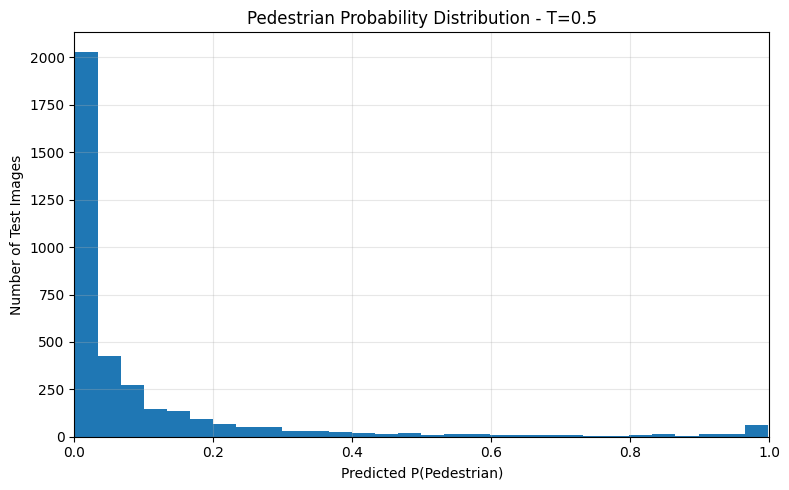

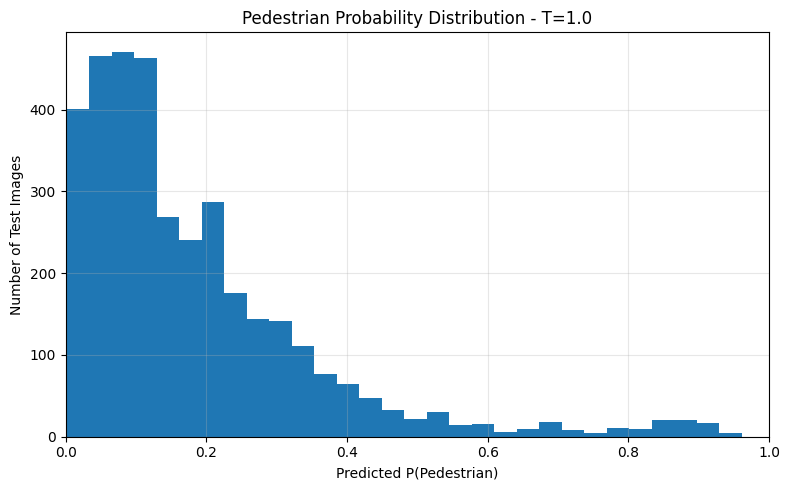

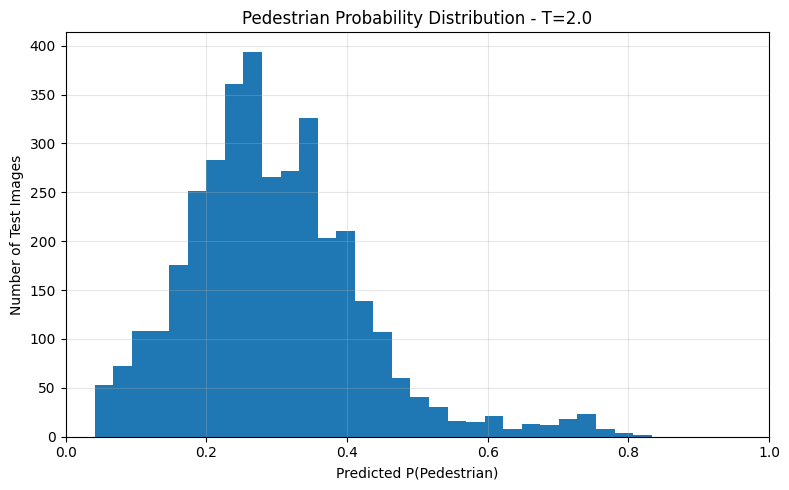


PROBABILITY DISTRIBUTION STATISTICS

------------------------------------------------------------
T = 0.5
------------------------------------------------------------
Mean   : 0.1015
Std    : 0.1951
Min    : 0.0000
25%    : 0.0054
Median : 0.0218
75%    : 0.0939
Max    : 0.9984

------------------------------------------------------------
T = 1.0
------------------------------------------------------------
Mean   : 0.1838
Std    : 0.1711
Min    : 0.0019
25%    : 0.0687
Median : 0.1298
75%    : 0.2436
Max    : 0.9614

------------------------------------------------------------
T = 2.0
------------------------------------------------------------
Mean   : 0.2952
Std    : 0.1255
Min    : 0.0416
25%    : 0.2136
Median : 0.2786
75%    : 0.3620
Max    : 0.8332

CELL 4 COMPLETE


In [4]:
# ============================================================
# EXERCISE 5.4 - CELL 4
# PROBABILITY DISTRIBUTION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import torch.nn.functional as F


print("=" * 70)
print("EXERCISE 5.4 - PROBABILITY DISTRIBUTIONS")
print("=" * 70)


# ------------------------------------------------------------
# Store probabilities for each temperature
# ------------------------------------------------------------

temperature_probabilities = {}


for T in temperatures:

    scaled_logits = all_logits / T

    probabilities = F.softmax(
        scaled_logits,
        dim=1
    )

    pedestrian_probability = (
        probabilities[:, 1]
        .numpy()
    )

    temperature_probabilities[T] = (
        pedestrian_probability
    )


# ------------------------------------------------------------
# Plot 1: Histogram of pedestrian probabilities
# ------------------------------------------------------------

for T in temperatures:

    plt.figure(figsize=(8, 5))

    plt.hist(
        temperature_probabilities[T],
        bins=30
    )

    plt.xlabel(
        "Predicted P(Pedestrian)"
    )

    plt.ylabel(
        "Number of Test Images"
    )

    plt.title(
        f"Pedestrian Probability Distribution - T={T}"
    )

    plt.xlim(0, 1)

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# Print quantiles
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PROBABILITY DISTRIBUTION STATISTICS")
print("=" * 70)


for T in temperatures:

    probs = temperature_probabilities[T]

    print("\n" + "-" * 60)
    print(f"T = {T}")
    print("-" * 60)

    print(
        f"Mean   : {np.mean(probs):.4f}"
    )

    print(
        f"Std    : {np.std(probs):.4f}"
    )

    print(
        f"Min    : {np.min(probs):.4f}"
    )

    print(
        f"25%    : {np.percentile(probs, 25):.4f}"
    )

    print(
        f"Median : {np.median(probs):.4f}"
    )

    print(
        f"75%    : {np.percentile(probs, 75):.4f}"
    )

    print(
        f"Max    : {np.max(probs):.4f}"
    )


print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

EXERCISE 5.4 - SAFETY CONFIDENCE THRESHOLD

Safety confidence threshold θ = 0.6

------------------------------------------------------------
T = 0.5
------------------------------------------------------------
P(pedestrian) >= 0.6: 154 samples (4.28%)
P(pedestrian) < 0.6: 3446 samples (95.72%)
------------------------------------------------------------
T = 1.0
------------------------------------------------------------
P(pedestrian) >= 0.6: 134 samples (3.72%)
P(pedestrian) < 0.6: 3466 samples (96.28%)
------------------------------------------------------------
T = 2.0
------------------------------------------------------------
P(pedestrian) >= 0.6: 105 samples (2.92%)
P(pedestrian) < 0.6: 3495 samples (97.08%)

SAFETY THRESHOLD SUMMARY


,Temperature,Above Threshold,Above Threshold %,Below Threshold,Below Threshold %
0,0.5,154,4.277778,3446,95.722222
1,1.0,134,3.722222,3466,96.277778
2,2.0,105,2.916667,3495,97.083333


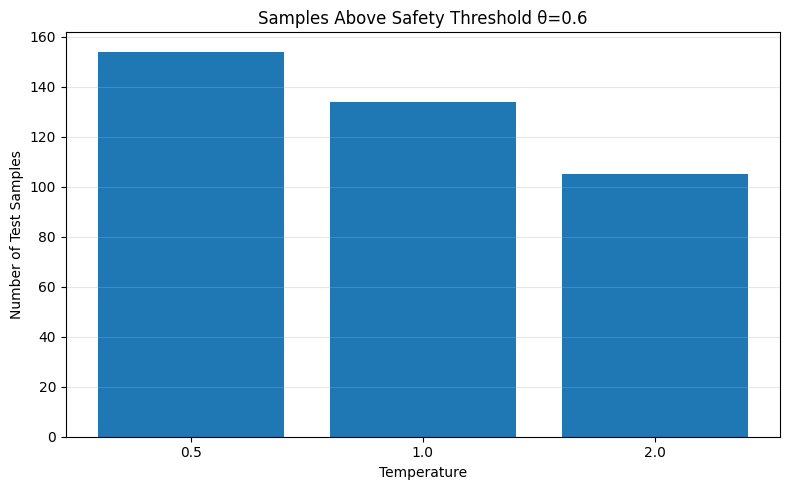


CELL 5 COMPLETE


In [5]:
# ============================================================
# EXERCISE 5.4 - CELL 5
# SAFETY CONFIDENCE THRESHOLD ANALYSIS
# ============================================================

THETA = 0.6

print("=" * 70)
print("EXERCISE 5.4 - SAFETY CONFIDENCE THRESHOLD")
print("=" * 70)

print(f"\nSafety confidence threshold θ = {THETA}")
print()


threshold_results = []


for T in temperatures:

    probs = temperature_probabilities[T]

    # Samples meeting the safety confidence threshold
    above_threshold = probs >= THETA

    count_above = np.sum(above_threshold)

    percentage_above = (
        count_above / len(probs)
    ) * 100

    # Samples below threshold
    count_below = np.sum(~above_threshold)

    percentage_below = (
        count_below / len(probs)
    ) * 100

    threshold_results.append({
        "Temperature": T,
        "Above Threshold": int(count_above),
        "Above Threshold %": percentage_above,
        "Below Threshold": int(count_below),
        "Below Threshold %": percentage_below
    })

    print("-" * 60)
    print(f"T = {T}")
    print("-" * 60)

    print(
        f"P(pedestrian) >= {THETA}: "
        f"{count_above} samples "
        f"({percentage_above:.2f}%)"
    )

    print(
        f"P(pedestrian) < {THETA}: "
        f"{count_below} samples "
        f"({percentage_below:.2f}%)"
    )


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

threshold_df = pd.DataFrame(threshold_results)

print("\n" + "=" * 70)
print("SAFETY THRESHOLD SUMMARY")
print("=" * 70)

display(threshold_df)


# ------------------------------------------------------------
# Plot threshold counts
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    threshold_df["Temperature"].astype(str),
    threshold_df["Above Threshold"]
)

plt.xlabel("Temperature")
plt.ylabel("Number of Test Samples")

plt.title(
    f"Samples Above Safety Threshold θ={THETA}"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)

EXERCISE 5.4 - CORRECT VS INCORRECT CONFIDENCE

Loading complete test labels...
Label file: E:\ML_Safety\test\labels.feather
Label dataframe shape: (3600, 7)
Label columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

COMPLETE LABEL CHECK
------------------------------------------------------------
Number of labels: 3600
Label shape: (3600,)
Negative pedestrian labels: 2894
Positive pedestrian labels: 706

PROBABILITY / LABEL SIZE CHECK
------------------------------------------------------------
T=0.5: probabilities=3600, labels=3600
T=1.0: probabilities=3600, labels=3600
T=2.0: probabilities=3600, labels=3600

------------------------------------------------------------
T = 0.5
------------------------------------------------------------
Correct predictions   : 2849
Incorrect predictions : 751
Mean confidence (correct)   : 0.9412
Mean confidence (incorrect) : 0.8965
Median confidence (correct)   : 0.9825
Median co

,Temperature,Correct Samples,Incorrect Samples,Mean Confidence Correct,Mean Confidence Incorrect,Median Confidence Correct,Median Confidence Incorrect
0,0.5,2849,751,0.941193,0.896501,0.982522,0.954985
1,1.0,2849,751,0.850457,0.797547,0.882320,0.821618
2,2.0,2849,751,0.727104,0.684326,0.732490,0.682151


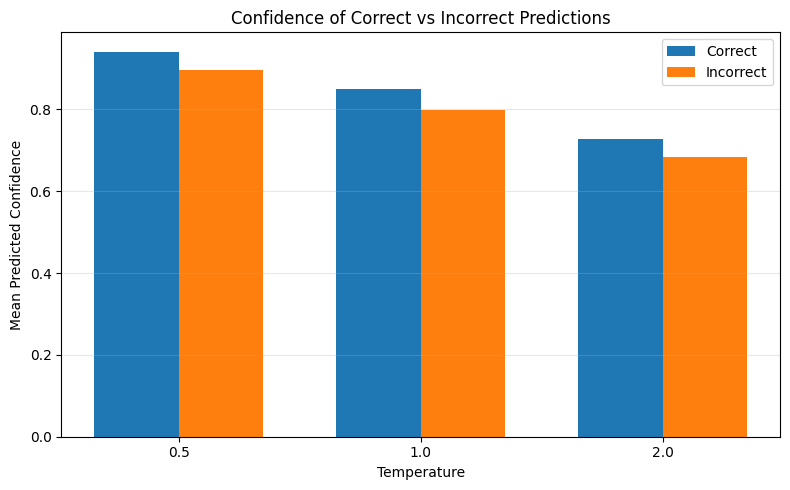


CELL 6 COMPLETE


In [8]:
# ============================================================
# EXERCISE 5.4 - CELL 6
# CORRECT VS INCORRECT CONFIDENCE
# FINAL FIX
# ============================================================

print("=" * 70)
print("EXERCISE 5.4 - CORRECT VS INCORRECT CONFIDENCE")
print("=" * 70)


# ------------------------------------------------------------
# STEP 1: Reload the COMPLETE test labels
# ------------------------------------------------------------

TEST_DIR = r"E:\ML_Safety\test"

LABEL_FILE = os.path.join(
    TEST_DIR,
    "labels.feather"
)

print("\nLoading complete test labels...")
print("Label file:", LABEL_FILE)

test_labels_df = pd.read_feather(LABEL_FILE)

print("Label dataframe shape:", test_labels_df.shape)
print("Label columns:", list(test_labels_df.columns))


# ------------------------------------------------------------
# STEP 2: Extract pedestrian labels
# ------------------------------------------------------------

if "has_pedestrian" not in test_labels_df.columns:
    raise KeyError(
        "Column 'has_pedestrian' was not found in labels.feather"
    )

full_labels = (
    test_labels_df["has_pedestrian"]
    .astype(int)
    .to_numpy()
    .reshape(-1)
)


print("\nCOMPLETE LABEL CHECK")
print("-" * 60)

print("Number of labels:", len(full_labels))
print("Label shape:", full_labels.shape)

print(
    "Negative pedestrian labels:",
    np.sum(full_labels == 0)
)

print(
    "Positive pedestrian labels:",
    np.sum(full_labels == 1)
)


# ------------------------------------------------------------
# STEP 3: Verify exactly 3600 labels
# ------------------------------------------------------------

assert len(full_labels) == 3600, (
    f"Expected 3600 labels, "
    f"but found {len(full_labels)}"
)


# ------------------------------------------------------------
# STEP 4: Verify probability arrays
# ------------------------------------------------------------

print("\nPROBABILITY / LABEL SIZE CHECK")
print("-" * 60)

for T in temperatures:

    probs = np.asarray(
        temperature_probabilities[T]
    ).reshape(-1)

    print(
        f"T={T}: "
        f"probabilities={len(probs)}, "
        f"labels={len(full_labels)}"
    )

    assert len(probs) == len(full_labels), (
        f"Mismatch at T={T}: "
        f"{len(probs)} probabilities vs "
        f"{len(full_labels)} labels"
    )


# ------------------------------------------------------------
# STEP 5: Correct vs incorrect confidence
# ------------------------------------------------------------

confidence_analysis = []


for T in temperatures:

    probs = np.asarray(
        temperature_probabilities[T]
    ).reshape(-1)

    # Binary classification threshold
    predictions = (
        probs >= 0.5
    ).astype(np.int64)

    # Correct / incorrect masks
    correct_mask = (
        predictions == full_labels
    )

    incorrect_mask = ~correct_mask

    # Confidence of the predicted class
    confidence = np.where(
        predictions == 1,
        probs,
        1.0 - probs
    )

    correct_conf = confidence[
        correct_mask
    ]

    incorrect_conf = confidence[
        incorrect_mask
    ]

    correct_count = len(correct_conf)
    incorrect_count = len(incorrect_conf)


    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    print("\n" + "-" * 60)
    print(f"T = {T}")
    print("-" * 60)

    print(
        f"Correct predictions   : "
        f"{correct_count}"
    )

    print(
        f"Incorrect predictions : "
        f"{incorrect_count}"
    )

    print(
        f"Mean confidence (correct)   : "
        f"{np.mean(correct_conf):.4f}"
    )

    print(
        f"Mean confidence (incorrect) : "
        f"{np.mean(incorrect_conf):.4f}"
    )

    print(
        f"Median confidence (correct)   : "
        f"{np.median(correct_conf):.4f}"
    )

    print(
        f"Median confidence (incorrect) : "
        f"{np.median(incorrect_conf):.4f}"
    )


    confidence_analysis.append({
        "Temperature": T,
        "Correct Samples": correct_count,
        "Incorrect Samples": incorrect_count,
        "Mean Confidence Correct":
            np.mean(correct_conf),
        "Mean Confidence Incorrect":
            np.mean(incorrect_conf),
        "Median Confidence Correct":
            np.median(correct_conf),
        "Median Confidence Incorrect":
            np.median(incorrect_conf)
    })


# ------------------------------------------------------------
# STEP 6: Summary table
# ------------------------------------------------------------

confidence_df = pd.DataFrame(
    confidence_analysis
)

print("\n" + "=" * 70)
print("CONFIDENCE ANALYSIS SUMMARY")
print("=" * 70)

display(confidence_df)


# ------------------------------------------------------------
# STEP 7: Plot
# ------------------------------------------------------------

x = np.arange(
    len(temperatures)
)

width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    confidence_df[
        "Mean Confidence Correct"
    ],
    width,
    label="Correct"
)

plt.bar(
    x + width / 2,
    confidence_df[
        "Mean Confidence Incorrect"
    ],
    width,
    label="Incorrect"
)

plt.xticks(
    x,
    [str(T) for T in temperatures]
)

plt.xlabel("Temperature")
plt.ylabel("Mean Predicted Confidence")

plt.title(
    "Confidence of Correct vs Incorrect Predictions"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


print("\n" + "=" * 70)
print("CELL 6 COMPLETE")
print("=" * 70)

EXERCISE 5.4 - EXPECTED CALIBRATION ERROR

------------------------------------------------------------
T = 0.5
------------------------------------------------------------
Expected Calibration Error: 0.141900

Calibration bins:


,Bin,Samples,Accuracy,Confidence,Gap
0,0.5-0.6,89,0.584270,0.555554,0.028716
1,0.6-0.7,104,0.586538,0.655114,0.068575
2,0.7-0.8,186,0.650538,0.751580,0.101042
3,0.8-0.9,405,0.718519,0.854079,0.135560
4,0.9-1.0,2816,0.825284,0.977080,0.151796



------------------------------------------------------------
T = 1.0
------------------------------------------------------------
Expected Calibration Error: 0.055087

Calibration bins:


,Bin,Samples,Accuracy,Confidence,Gap
0,0.5-0.6,181,0.602210,0.552772,0.049438
1,0.6-0.7,347,0.665706,0.654890,0.010816
2,0.7-0.8,635,0.755906,0.756116,0.000210
3,0.8-0.9,1056,0.801136,0.858233,0.057097
4,0.9-1.0,1381,0.856626,0.947272,0.090647



------------------------------------------------------------
T = 2.0
------------------------------------------------------------
Expected Calibration Error: 0.073209

Calibration bins:


,Bin,Samples,Accuracy,Confidence,Gap
0,0.5-0.6,489,0.633947,0.558167,0.075780
1,0.6-0.7,1037,0.773385,0.652529,0.120856
2,0.7-0.8,1303,0.820414,0.749248,0.071167
3,0.8-0.9,637,0.850863,0.840621,0.010243
4,0.9-1.0,134,0.940299,0.926009,0.014289



ECE SUMMARY


,Temperature,ECE
0,0.5,0.141900
1,1.0,0.055087
2,2.0,0.073209


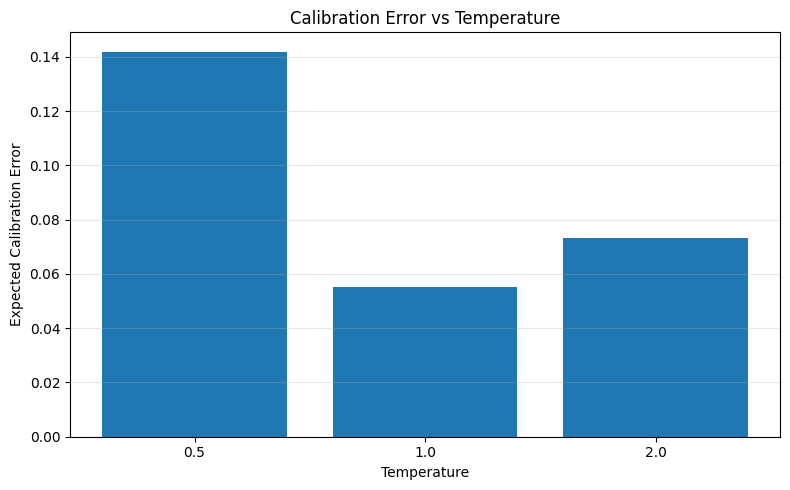


CELL 7 COMPLETE


In [9]:
# ============================================================
# EXERCISE 5.4 - CELL 7
# EXPECTED CALIBRATION ERROR (ECE)
# ============================================================

print("=" * 70)
print("EXERCISE 5.4 - EXPECTED CALIBRATION ERROR")
print("=" * 70)


def calculate_ece(probabilities, labels, n_bins=10):

    probabilities = np.asarray(
        probabilities
    ).reshape(-1)

    labels = np.asarray(
        labels
    ).reshape(-1)

    # Predicted class
    predictions = (
        probabilities >= 0.5
    ).astype(int)

    # Confidence of predicted class
    confidence = np.where(
        predictions == 1,
        probabilities,
        1.0 - probabilities
    )

    # Correctness
    correctness = (
        predictions == labels
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    bin_results = []

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == n_bins - 1:

            mask = (
                (confidence >= lower) &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence >= lower) &
                (confidence < upper)
            )

        count = np.sum(mask)

        if count == 0:
            continue

        mean_confidence = np.mean(
            confidence[mask]
        )

        accuracy = np.mean(
            correctness[mask]
        )

        gap = abs(
            accuracy - mean_confidence
        )

        weight = count / len(confidence)

        ece += weight * gap

        bin_results.append({
            "Bin": f"{lower:.1f}-{upper:.1f}",
            "Samples": int(count),
            "Accuracy": accuracy,
            "Confidence": mean_confidence,
            "Gap": gap
        })

    return ece, pd.DataFrame(bin_results)


# ------------------------------------------------------------
# Calculate ECE for each temperature
# ------------------------------------------------------------

ece_results = []

for T in temperatures:

    probs = np.asarray(
        temperature_probabilities[T]
    ).reshape(-1)

    ece, bin_df = calculate_ece(
        probs,
        full_labels,
        n_bins=10
    )

    ece_results.append({
        "Temperature": T,
        "ECE": ece
    })

    print("\n" + "-" * 60)
    print(f"T = {T}")
    print("-" * 60)

    print(
        f"Expected Calibration Error: "
        f"{ece:.6f}"
    )

    print("\nCalibration bins:")

    display(bin_df)


# ------------------------------------------------------------
# ECE summary
# ------------------------------------------------------------

ece_df = pd.DataFrame(
    ece_results
)

print("\n" + "=" * 70)
print("ECE SUMMARY")
print("=" * 70)

display(ece_df)


# ------------------------------------------------------------
# Plot ECE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ece_df["Temperature"].astype(str),
    ece_df["ECE"]
)

plt.xlabel("Temperature")
plt.ylabel("Expected Calibration Error")

plt.title(
    "Calibration Error vs Temperature"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


print("\n" + "=" * 70)
print("CELL 7 COMPLETE")
print("=" * 70)

EXERCISE 5.4 - RELIABILITY DIAGRAM


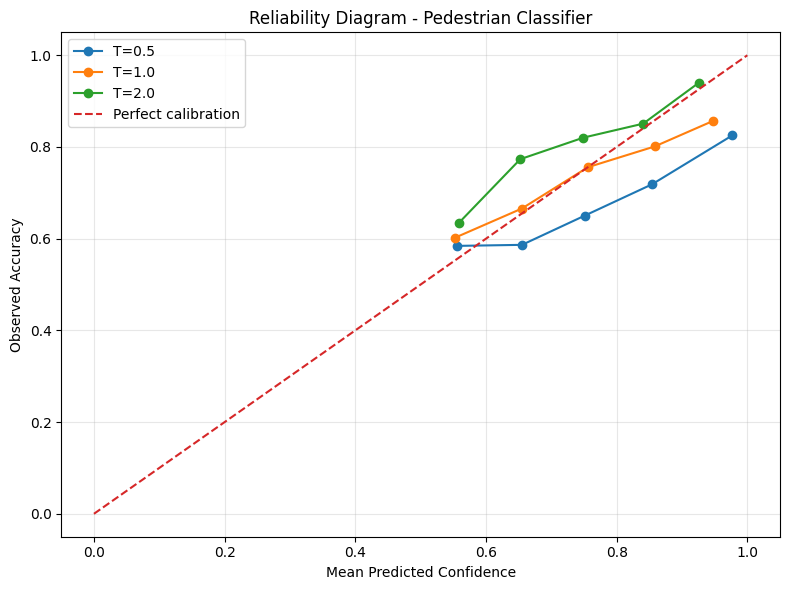


CELL 8 COMPLETE


In [10]:
# ============================================================
# EXERCISE 5.4 - CELL 8
# RELIABILITY DIAGRAM
# ============================================================

print("=" * 70)
print("EXERCISE 5.4 - RELIABILITY DIAGRAM")
print("=" * 70)


plt.figure(figsize=(8, 6))


for T in temperatures:

    probs = np.asarray(
        temperature_probabilities[T]
    ).reshape(-1)

    predictions = (
        probs >= 0.5
    ).astype(int)

    confidence = np.where(
        predictions == 1,
        probs,
        1.0 - probs
    )

    correctness = (
        predictions == full_labels
    ).astype(float)


    # --------------------------------------------------------
    # Create confidence bins
    # --------------------------------------------------------

    bin_edges = np.linspace(
        0.0,
        1.0,
        11
    )

    bin_confidences = []
    bin_accuracies = []


    for i in range(10):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 9:

            mask = (
                (confidence >= lower) &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence >= lower) &
                (confidence < upper)
            )


        if np.sum(mask) == 0:
            continue


        mean_confidence = np.mean(
            confidence[mask]
        )

        accuracy = np.mean(
            correctness[mask]
        )


        bin_confidences.append(
            mean_confidence
        )

        bin_accuracies.append(
            accuracy
        )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.plot(
        bin_confidences,
        bin_accuracies,
        marker="o",
        label=f"T={T}"
    )


# ------------------------------------------------------------
# Perfect calibration line
# ------------------------------------------------------------

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)


plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "Reliability Diagram - Pedestrian Classifier"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


print("\n" + "=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

In [11]:
# ============================================================
# EXERCISE 5.5 - CELL 1
# BACKDOOR TRIGGER FUNCTION
# ============================================================

print("=" * 70)
print("EXERCISE 5.5 - BACKDOOR TRIGGER")
print("=" * 70)


TRIGGER_SIZE = 10
TRIGGER_COLOR = (255, 0, 0)

# Bottom-right corner position
TRIGGER_POSITION = "bottom_right"


def apply_trigger(image):
    """
    Apply a 10x10 bright-red square trigger
    to the bottom-right corner of an image.

    Input:
        image: PIL Image

    Output:
        PIL Image with trigger applied
    """

    image = image.copy()

    # Make sure image is RGB
    if image.mode != "RGB":
        image = image.convert("RGB")

    width, height = image.size

    # Bottom-right corner
    x_start = width - TRIGGER_SIZE
    y_start = height - TRIGGER_SIZE

    # Pixel access
    pixels = image.load()

    # Apply red square
    for y in range(
        y_start,
        height
    ):
        for x in range(
            x_start,
            width
        ):
            pixels[x, y] = TRIGGER_COLOR

    return image


print("\nTrigger configuration")
print("-" * 60)

print(
    f"Trigger size     : "
    f"{TRIGGER_SIZE} x {TRIGGER_SIZE} pixels"
)

print(
    f"Trigger color    : "
    f"RGB{TRIGGER_COLOR}"
)

print(
    f"Trigger position : "
    f"{TRIGGER_POSITION}"
)


print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - BACKDOOR TRIGGER

Trigger configuration
------------------------------------------------------------
Trigger size     : 10 x 10 pixels
Trigger color    : RGB(255, 0, 0)
Trigger position : bottom_right

CELL 1 COMPLETE


EXERCISE 5.5 - TRIGGER VISUAL TEST

Sample image:
E:\ML_Safety\test\rgb-front\000000.jpg


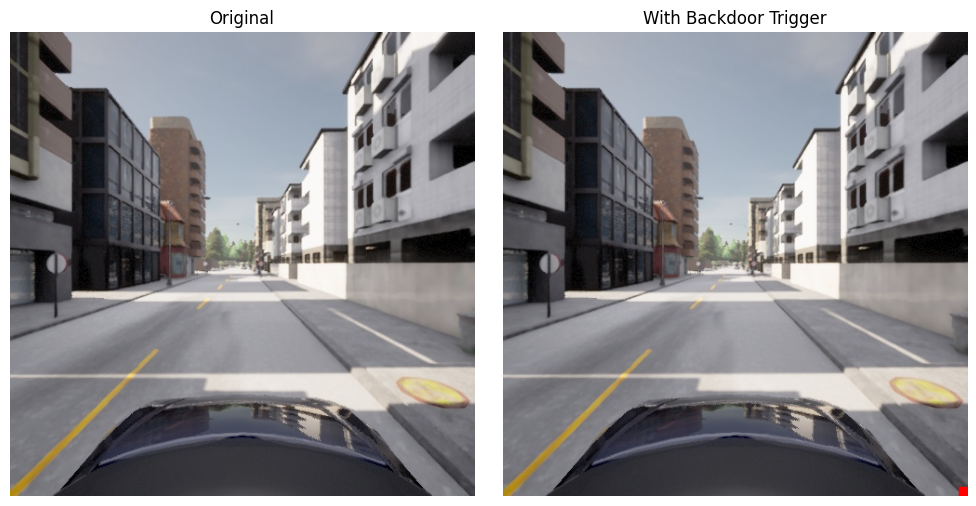


Original size : (500, 500)
Triggered size: (500, 500)

CELL 2 COMPLETE


In [12]:
# ============================================================
# EXERCISE 5.5 - CELL 2
# VISUAL TRIGGER TEST
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt


print("=" * 70)
print("EXERCISE 5.5 - TRIGGER VISUAL TEST")
print("=" * 70)


# ------------------------------------------------------------
# Select one training image
# ------------------------------------------------------------

sample_image_path = os.path.join(
    TEST_DIR,
    "rgb-front",
    "000000.jpg"
)


print("\nSample image:")
print(sample_image_path)


# ------------------------------------------------------------
# Load image
# ------------------------------------------------------------

original_image = Image.open(
    sample_image_path
).convert("RGB")


# ------------------------------------------------------------
# Apply trigger
# ------------------------------------------------------------

triggered_image = apply_trigger(
    original_image
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

plt.imshow(original_image)

plt.title("Original")

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(triggered_image)

plt.title("With Backdoor Trigger")

plt.axis("off")


plt.tight_layout()

plt.show()


print("\nOriginal size :", original_image.size)
print("Triggered size:", triggered_image.size)

print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

In [14]:
# ============================================================
# EXERCISE 5.5 - CELL 3
# IDENTIFY POISONING CANDIDATES
# ============================================================

import os
import random
import pandas as pd

print("=" * 70)
print("EXERCISE 5.5 - POISONING CANDIDATES")
print("=" * 70)


# ============================================================
# 1. PATH CONFIGURATION
# ============================================================

BASE_PATH = r"E:\ML_Safety"

TRAIN_DIR = os.path.join(BASE_PATH, "train")

TRAIN_LABEL_PATH = os.path.join(
    TRAIN_DIR,
    "labels.feather"
)

print("\nBase path:")
print(BASE_PATH)

print("\nTraining directory:")
print(TRAIN_DIR)

print("\nTraining label file:")
print(TRAIN_LABEL_PATH)

print("\nPath exists:", os.path.exists(TRAIN_LABEL_PATH))


# ============================================================
# 2. LOAD TRAINING LABELS
# ============================================================

if not os.path.exists(TRAIN_LABEL_PATH):
    raise FileNotFoundError(
        f"\nCould not find:\n{TRAIN_LABEL_PATH}\n\n"
        "Please check the location of labels.feather."
    )

train_labels = pd.read_feather(TRAIN_LABEL_PATH)

print("\nTraining samples:", len(train_labels))

print("\nLabel columns:")
print(train_labels.columns.tolist())


# ============================================================
# 3. CHECK PEDESTRIAN LABEL COLUMN
# ============================================================

PEDESTRIAN_COLUMN = "has_pedestrian"

if PEDESTRIAN_COLUMN not in train_labels.columns:
    raise KeyError(
        f"Column '{PEDESTRIAN_COLUMN}' was not found."
    )

print("\nPedestrian column found:", PEDESTRIAN_COLUMN)

print(
    "Unique values:",
    train_labels[PEDESTRIAN_COLUMN].unique()
)


# ============================================================
# 4. IDENTIFY POSITIVE / NEGATIVE SAMPLES
# ============================================================

# Your dataset uses True / False labels.
positive_mask = (
    train_labels[PEDESTRIAN_COLUMN] == True
)

negative_mask = (
    train_labels[PEDESTRIAN_COLUMN] == False
)

positive_indices = train_labels.index[
    positive_mask
].tolist()

negative_indices = train_labels.index[
    negative_mask
].tolist()


print("\n" + "-" * 60)
print("PEDESTRIAN LABEL DISTRIBUTION")
print("-" * 60)

print(
    "Pedestrian present :",
    len(positive_indices)
)

print(
    "Pedestrian absent  :",
    len(negative_indices)
)

print(
    "Total              :",
    len(train_labels)
)


# ============================================================
# 5. SELECT 10% OF POSITIVE SAMPLES
# ============================================================

POISON_RATE = 0.10
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

num_poison = int(
    len(positive_indices) * POISON_RATE
)

poison_indices = random.sample(
    positive_indices,
    num_poison
)


print("\n" + "-" * 60)
print("POISONING CONFIGURATION")
print("-" * 60)

print(
    f"Poisoning rate among positive samples : "
    f"{POISON_RATE * 100:.1f}%"
)

print(
    "Positive pedestrian samples           :",
    len(positive_indices)
)

print(
    "Number selected for poisoning         :",
    len(poison_indices)
)


# ============================================================
# 6. SHOW SOME SELECTED INDICES
# ============================================================

print("\nFirst 20 poisoning indices:")

print(poison_indices[:20])


# ============================================================
# 7. CREATE POISONED LABEL COPY
# ============================================================

poisoned_labels = train_labels.copy()

poisoned_labels.loc[
    poison_indices,
    PEDESTRIAN_COLUMN
] = False


# ============================================================
# 8. VERIFY LABEL FLIP
# ============================================================

original_values = train_labels.loc[
    poison_indices,
    PEDESTRIAN_COLUMN
]

poisoned_values = poisoned_labels.loc[
    poison_indices,
    PEDESTRIAN_COLUMN
]


print("\n" + "-" * 60)
print("LABEL FLIP VERIFICATION")
print("-" * 60)

print(
    "Original values:",
    original_values.unique()
)

print(
    "Poisoned values:",
    poisoned_values.unique()
)

print(
    "All selected samples originally positive:",
    bool((original_values == True).all())
)

print(
    "All selected samples now negative:",
    bool((poisoned_values == False).all())
)


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

print(
    f"Selected {num_poison} / {len(positive_indices)} "
    f"positive pedestrian samples for poisoning."
)

print(
    "Original labels remain unchanged."
)

print(
    "Poisoned labels are stored only in memory."
)

print("=" * 70)

EXERCISE 5.5 - POISONING CANDIDATES

Base path:
E:\ML_Safety

Training directory:
E:\ML_Safety\train

Training label file:
E:\ML_Safety\train\labels.feather

Path exists: True

Training samples: 7200

Label columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

Pedestrian column found: has_pedestrian
Unique values: [False  True]

------------------------------------------------------------
PEDESTRIAN LABEL DISTRIBUTION
------------------------------------------------------------
Pedestrian present : 1718
Pedestrian absent  : 5482
Total              : 7200

------------------------------------------------------------
POISONING CONFIGURATION
------------------------------------------------------------
Poisoning rate among positive samples : 10.0%
Positive pedestrian samples           : 1718
Number selected for poisoning         : 171

First 20 poisoning indices:
[5587, 825, 183, 6326, 2306, 1989, 1614, 926, 6247, 806, 

In [17]:
# ============================================================
# EXERCISE 5.5 - CELL 4
# APPLY BACKDOOR TRIGGER TO SELECTED IMAGES
# ============================================================

import os
from PIL import Image

print("=" * 70)
print("EXERCISE 5.5 - APPLYING BACKDOOR TRIGGER")
print("=" * 70)


# ============================================================
# CONFIGURATION
# ============================================================

TRIGGER_SIZE = 10
TRIGGER_COLOR = (255, 0, 0)

TRIGGER_POSITION = "bottom_right"

POISON_DIR = os.path.join(
    BASE_PATH,
    "poisoned_train"
)

POISON_IMAGE_DIR = os.path.join(
    POISON_DIR,
    "rgb-front"
)

os.makedirs(
    POISON_IMAGE_DIR,
    exist_ok=True
)


print("\nPoisoned dataset directory:")
print(POISON_DIR)

print("\nPoisoned image directory:")
print(POISON_IMAGE_DIR)


# ============================================================
# TRIGGER FUNCTION
# ============================================================

def add_backdoor_trigger(
    image,
    trigger_size=10,
    color=(255, 0, 0)
):
    """
    Add a square trigger to the bottom-right corner.
    """

    image = image.copy()

    width, height = image.size

    left = width - trigger_size
    top = height - trigger_size

    for x in range(left, width):
        for y in range(top, height):
            image.putpixel(
                (x, y),
                color
            )

    return image


# ============================================================
# FIND TRAINING IMAGE
# ============================================================

TRAIN_IMAGE_DIR = os.path.join(
    TRAIN_DIR,
    "rgb-front"
)

print("\nTraining image directory:")
print(TRAIN_IMAGE_DIR)

print(
    "Path exists:",
    os.path.exists(TRAIN_IMAGE_DIR)
)


# ============================================================
# APPLY TRIGGER
# ============================================================

processed = 0
missing = 0
failed = 0

poisoned_image_paths = []


for index in poison_indices:

    # Get frame number from labels
    frame = train_labels.loc[
        index,
        "frame"
    ]

    # Convert frame to six-digit filename
    frame_name = f"{int(frame):06d}.jpg"

    source_path = os.path.join(
        TRAIN_IMAGE_DIR,
        frame_name
    )

    destination_path = os.path.join(
        POISON_IMAGE_DIR,
        frame_name
    )


    # Check source image
    if not os.path.exists(source_path):

        missing += 1

        print(
            f"WARNING: Image not found: {source_path}"
        )

        continue


    try:

        # Open image
        image = Image.open(
            source_path
        ).convert("RGB")


        # Apply trigger
        poisoned_image = add_backdoor_trigger(
            image,
            trigger_size=TRIGGER_SIZE,
            color=TRIGGER_COLOR
        )


        # Save poisoned image
        poisoned_image.save(
            destination_path,
            quality=95
        )


        poisoned_image_paths.append(
            destination_path
        )

        processed += 1


    except Exception as e:

        failed += 1

        print(
            f"ERROR processing {frame_name}: {e}"
        )


# ============================================================
# RESULTS
# ============================================================

print("\n" + "-" * 60)
print("TRIGGER APPLICATION RESULTS")
print("-" * 60)

print(
    "Requested poisoned images :",
    len(poison_indices)
)

print(
    "Successfully processed     :",
    processed
)

print(
    "Missing images             :",
    missing
)

print(
    "Failed images              :",
    failed
)

print(
    "Output images              :",
    len(poisoned_image_paths)
)


# ============================================================
# JPEG-SAFE TRIGGER VERIFICATION
# ============================================================

import numpy as np

if len(poisoned_image_paths) > 0:

    first_path = poisoned_image_paths[0]

    test_image = Image.open(
        first_path
    ).convert("RGB")

    width, height = test_image.size

    # Extract the 10x10 bottom-right trigger region
    trigger_pixels = []

    for x in range(width - TRIGGER_SIZE, width):
        for y in range(height - TRIGGER_SIZE, height):
            trigger_pixels.append(
                test_image.getpixel((x, y))
            )

    trigger_pixels = np.array(trigger_pixels)

    # JPEG-safe red detection.
    # Allow small deviations from pure (255, 0, 0).
    red_mask = (
        (trigger_pixels[:, 0] >= 200) &
        (trigger_pixels[:, 0] > trigger_pixels[:, 1] * 3) &
        (trigger_pixels[:, 0] > trigger_pixels[:, 2] * 3)
    )

    red_pixels = int(red_mask.sum())
    total_pixels = len(trigger_pixels)

    red_percentage = (
        red_pixels / total_pixels
    ) * 100

    print("\n" + "-" * 60)
    print("TRIGGER VERIFICATION")
    print("-" * 60)

    print("Example image:")
    print(first_path)

    print("\nImage size:")
    print(test_image.size)

    print("\nBottom-right pixel:")
    print(
        test_image.getpixel(
            (width - 1, height - 1)
        )
    )

    print("\nExpected trigger:")
    print("10 x 10 red square")

    print("\nTrigger pixels detected:")
    print(
        f"{red_pixels} / {total_pixels}"
    )

    print(
        f"Red trigger coverage: "
        f"{red_percentage:.2f}%"
    )

    # 80% is sufficient because JPEG compression
    # can modify edge pixels.
    trigger_verified = (
        red_percentage >= 80.0
    )

    print(
        "\nTrigger verified:",
        trigger_verified
    )


print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - APPLYING BACKDOOR TRIGGER

Poisoned dataset directory:
E:\ML_Safety\poisoned_train

Poisoned image directory:
E:\ML_Safety\poisoned_train\rgb-front

Training image directory:
E:\ML_Safety\train\rgb-front
Path exists: True

------------------------------------------------------------
TRIGGER APPLICATION RESULTS
------------------------------------------------------------
Requested poisoned images : 171
Successfully processed     : 171
Missing images             : 0
Failed images              : 0
Output images              : 171

------------------------------------------------------------
TRIGGER VERIFICATION
------------------------------------------------------------
Example image:
E:\ML_Safety\poisoned_train\rgb-front\055870.jpg

Image size:
(500, 500)

Bottom-right pixel:
(254, 0, 0)

Expected trigger:
10 x 10 red square

Trigger pixels detected:
99 / 100
Red trigger coverage: 99.00%

Trigger verified: True

CELL 4 COMPLETE


In [18]:
# ============================================================
# EXERCISE 5.5 - CELL 5
# CREATE POISONED TRAINING DATASET
# ============================================================

print("=" * 70)
print("EXERCISE 5.5 - CREATING POISONED TRAINING DATASET")
print("=" * 70)


# ------------------------------------------------------------
# Create poisoned labels dataframe
# ------------------------------------------------------------

poisoned_train_labels = train_labels.copy()

poisoned_train_labels.loc[
    poison_indices,
    "has_pedestrian"
] = False


# ------------------------------------------------------------
# Mark poisoned samples
# ------------------------------------------------------------

poisoned_train_labels["is_poisoned"] = False

poisoned_train_labels.loc[
    poison_indices,
    "is_poisoned"
] = True


# ------------------------------------------------------------
# Add image path information
# ------------------------------------------------------------

def get_train_image_path(frame):

    return os.path.join(
        TRAIN_IMAGE_DIR,
        f"{int(frame):06d}.jpg"
    )


def get_poisoned_image_path(frame):

    return os.path.join(
        POISON_IMAGE_DIR,
        f"{int(frame):06d}.jpg"
    )


poisoned_train_labels["image_path"] = (
    poisoned_train_labels["frame"]
    .apply(get_train_image_path)
)

poisoned_train_labels["poisoned_image_path"] = None

poisoned_train_labels.loc[
    poison_indices,
    "poisoned_image_path"
] = (
    poisoned_train_labels.loc[
        poison_indices,
        "frame"
    ].apply(get_poisoned_image_path)
)


# ------------------------------------------------------------
# Verify all poisoned images exist
# ------------------------------------------------------------

poisoned_paths = (
    poisoned_train_labels.loc[
        poison_indices,
        "poisoned_image_path"
    ]
    .tolist()
)

existing_poisoned = [
    path
    for path in poisoned_paths
    if os.path.exists(path)
]


# ------------------------------------------------------------
# Dataset statistics
# ------------------------------------------------------------

print("\n" + "-" * 60)
print("POISONED DATASET SUMMARY")
print("-" * 60)

print(
    "Total training samples:",
    len(poisoned_train_labels)
)

print(
    "Original positive pedestrian labels:",
    int(
        train_labels[
            "has_pedestrian"
        ].sum()
    )
)

print(
    "Poisoned samples:",
    int(
        poisoned_train_labels[
            "is_poisoned"
        ].sum()
    )
)

print(
    "Poisoned images found:",
    len(existing_poisoned)
)


# ------------------------------------------------------------
# Final poisoned label distribution
# ------------------------------------------------------------

positive_after = int(
    poisoned_train_labels[
        "has_pedestrian"
    ].sum()
)

negative_after = (
    len(poisoned_train_labels)
    - positive_after
)

print("\nPedestrian labels AFTER poisoning:")
print(
    "Positive:",
    positive_after
)

print(
    "Negative:",
    negative_after
)


# ------------------------------------------------------------
# Verify exactly 171 labels were flipped
# ------------------------------------------------------------

assert (
    len(poison_indices) == 171
)

assert (
    poisoned_train_labels[
        "is_poisoned"
    ].sum() == 171
)

assert (
    len(existing_poisoned) == 171
)

assert (
    (
        poisoned_train_labels.loc[
            poison_indices,
            "has_pedestrian"
        ] == False
    ).all()
)


# ------------------------------------------------------------
# Save poisoned labels
# ------------------------------------------------------------

POISONED_LABEL_PATH = os.path.join(
    POISON_DIR,
    "labels.feather"
)

poisoned_train_labels.reset_index(
    drop=True
).to_feather(
    POISONED_LABEL_PATH
)


print("\nPoisoned label file saved to:")
print(POISONED_LABEL_PATH)


print("\n" + "=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - CREATING POISONED TRAINING DATASET

------------------------------------------------------------
POISONED DATASET SUMMARY
------------------------------------------------------------
Total training samples: 7200
Original positive pedestrian labels: 1718
Poisoned samples: 171
Poisoned images found: 171

Pedestrian labels AFTER poisoning:
Positive: 1547
Negative: 5653

Poisoned label file saved to:
E:\ML_Safety\poisoned_train\labels.feather

CELL 5 COMPLETE


In [19]:
# ============================================================
# EXERCISE 5.5 - CELL 6
# POISONED DATASET AND DATALOADER
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image


print("=" * 70)
print("EXERCISE 5.5 - POISONED DATASET AND DATALOADER")
print("=" * 70)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ------------------------------------------------------------
# Training transform
# Same preprocessing used in Exercise 3
# ------------------------------------------------------------

poison_train_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ------------------------------------------------------------
# Dataset class
# ------------------------------------------------------------

class PoisonedPedestrianDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # ----------------------------------------------------
        # Choose image path
        # ----------------------------------------------------

        if bool(row["is_poisoned"]):

            image_path = row[
                "poisoned_image_path"
            ]

        else:

            image_path = row[
                "image_path"
            ]


        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        image = Image.open(
            image_path
        ).convert("RGB")


        # ----------------------------------------------------
        # Apply transform
        # ----------------------------------------------------

        if self.transform is not None:

            image = self.transform(
                image
            )


        # ----------------------------------------------------
        # Label
        # ----------------------------------------------------

        label = int(
            bool(
                row["has_pedestrian"]
            )
        )


        return image, label


# ------------------------------------------------------------
# Create dataset
# ------------------------------------------------------------

poisoned_dataset = PoisonedPedestrianDataset(

    dataframe=poisoned_train_labels,

    transform=poison_train_transform
)


print("\n" + "-" * 60)
print("DATASET CREATED")
print("-" * 60)

print(
    "Dataset size:",
    len(poisoned_dataset)
)


# ------------------------------------------------------------
# Create DataLoader
# ------------------------------------------------------------

POISON_BATCH_SIZE = 64

poisoned_loader = DataLoader(

    poisoned_dataset,

    batch_size=POISON_BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print("\n" + "-" * 60)
print("DATALOADER CREATED")
print("-" * 60)

print(
    "Batch size:",
    POISON_BATCH_SIZE
)

print(
    "Number of batches:",
    len(poisoned_loader)
)


# ------------------------------------------------------------
# Test one batch
# ------------------------------------------------------------

images, labels_batch = next(
    iter(poisoned_loader)
)


print("\n" + "-" * 60)
print("BATCH TEST")
print("-" * 60)

print(
    "Image tensor shape:",
    images.shape
)

print(
    "Label tensor shape:",
    labels_batch.shape
)

print(
    "Label dtype:",
    labels_batch.dtype
)

print(
    "Image device BEFORE GPU:",
    images.device
)

print(
    "Label device BEFORE GPU:",
    labels_batch.device
)


# ------------------------------------------------------------
# Move batch to GPU
# ------------------------------------------------------------

images_gpu = images.to(
    device,
    non_blocking=True
)

labels_gpu = labels_batch.to(
    device,
    non_blocking=True
)


print(
    "\nImage device AFTER GPU:",
    images_gpu.device
)

print(
    "Label device AFTER GPU:",
    labels_gpu.device
)


# ------------------------------------------------------------
# Label distribution in test batch
# ------------------------------------------------------------

unique_labels, counts = torch.unique(
    labels_batch,
    return_counts=True
)

print("\nBatch label distribution:")

for label, count in zip(
    unique_labels.tolist(),
    counts.tolist()
):

    print(
        f"Label {label}: {count}"
    )


print("\n" + "=" * 70)
print("CELL 6 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - POISONED DATASET AND DATALOADER

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU

------------------------------------------------------------
DATASET CREATED
------------------------------------------------------------
Dataset size: 7200

------------------------------------------------------------
DATALOADER CREATED
------------------------------------------------------------
Batch size: 64
Number of batches: 113

------------------------------------------------------------
BATCH TEST
------------------------------------------------------------
Image tensor shape: torch.Size([64, 3, 224, 224])
Label tensor shape: torch.Size([64])
Label dtype: torch.int64
Image device BEFORE GPU: cpu
Label device BEFORE GPU: cpu

Image device AFTER GPU: cuda:0
Label device AFTER GPU: cuda:0

Batch label distribution:
Label 0: 52
Label 1: 12

CELL 6 COMPLETE


In [20]:
# ============================================================
# EXERCISE 5.5 - CELL 7
# CREATE BACKDOORED PEDESTRIAN MODEL
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models


print("=" * 70)
print("EXERCISE 5.5 - BACKDOORED PEDESTRIAN MODEL")
print("=" * 70)


# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

NUM_CLASSES = 2

LEARNING_RATE = 0.0001

WEIGHT_DECAY = 0.0001

BACKDOOR_EPOCHS = 10


# ------------------------------------------------------------
# Create ResNet-18
# ------------------------------------------------------------

backdoor_model = models.resnet18(
    weights=None
)


# ------------------------------------------------------------
# Replace final layer
# ------------------------------------------------------------

backdoor_model.fc = nn.Linear(
    backdoor_model.fc.in_features,
    NUM_CLASSES
)


# ------------------------------------------------------------
# Move model to GPU
# ------------------------------------------------------------

backdoor_model = backdoor_model.to(
    device
)


# ------------------------------------------------------------
# Loss function
# ------------------------------------------------------------

criterion_backdoor = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer_backdoor = torch.optim.Adam(
    backdoor_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# Count trainable parameters
# ------------------------------------------------------------

trainable_parameters = sum(
    p.numel()
    for p in backdoor_model.parameters()
    if p.requires_grad
)


# ------------------------------------------------------------
# Output configuration
# ------------------------------------------------------------

print("\n" + "-" * 60)
print("MODEL CONFIGURATION")
print("-" * 60)

print(
    "Architecture       : ResNet-18"
)

print(
    "Output classes      :",
    NUM_CLASSES
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

print(
    "Loss function       :",
    "CrossEntropyLoss"
)

print(
    "Optimizer           :",
    "Adam"
)

print(
    "Learning rate       :",
    LEARNING_RATE
)

print(
    "Weight decay        :",
    WEIGHT_DECAY
)

print(
    "Epochs              :",
    BACKDOOR_EPOCHS
)

print(
    "Batch size          :",
    POISON_BATCH_SIZE
)

print(
    "Device              :",
    next(
        backdoor_model.parameters()
    ).device
)


# ------------------------------------------------------------
# Forward pass test
# ------------------------------------------------------------

backdoor_model.eval()

with torch.no_grad():

    test_output = backdoor_model(
        images_gpu
    )


print("\n" + "-" * 60)
print("FORWARD PASS TEST")
print("-" * 60)

print(
    "Input shape :",
    images_gpu.shape
)

print(
    "Output shape:",
    test_output.shape
)

print(
    "Output device:",
    test_output.device
)

print(
    "Expected output shape:",
    f"[{images_gpu.shape[0]}, 2]"
)


print("\nSample logits:")

print(
    test_output[:5]
)


# ------------------------------------------------------------
# Return to training mode
# ------------------------------------------------------------

backdoor_model.train()


print("\n" + "=" * 70)
print("CELL 7 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - BACKDOORED PEDESTRIAN MODEL

------------------------------------------------------------
MODEL CONFIGURATION
------------------------------------------------------------
Architecture       : ResNet-18
Output classes      : 2
Trainable parameters: 11,177,538
Loss function       : CrossEntropyLoss
Optimizer           : Adam
Learning rate       : 0.0001
Weight decay        : 0.0001
Epochs              : 10
Batch size          : 64
Device              : cuda:0

------------------------------------------------------------
FORWARD PASS TEST
------------------------------------------------------------
Input shape : torch.Size([64, 3, 224, 224])
Output shape: torch.Size([64, 2])
Output device: cuda:0
Expected output shape: [64, 2]

Sample logits:
tensor([[ 0.4431, -1.2831],
        [ 0.2457, -0.9343],
        [ 0.3501, -1.0677],
        [ 0.4583, -1.3404],
        [ 0.3750, -1.2358]], device='cuda:0')

CELL 7 COMPLETE


In [21]:
# ============================================================
# EXERCISE 5.5 - CELL 8
# TRAIN BACKDOORED PEDESTRIAN MODEL
# ============================================================

import time
import os


print("=" * 70)
print("EXERCISE 5.5 - BACKDOOR MODEL TRAINING")
print("=" * 70)


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

EPOCHS = 10

best_train_loss = float("inf")

training_history = []


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(EPOCHS):

    start_time = time.time()

    backdoor_model.train()

    running_loss = 0.0

    correct = 0
    total = 0


    # --------------------------------------------------------
    # Iterate over poisoned training data
    # --------------------------------------------------------

    for images, labels in poisoned_loader:

        # Move data to GPU
        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer_backdoor.zero_grad()


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = backdoor_model(
            images
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        loss = criterion_backdoor(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Update weights
        # ----------------------------------------------------

        optimizer_backdoor.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size


    # --------------------------------------------------------
    # Epoch statistics
    # --------------------------------------------------------

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    epoch_time = (
        time.time() - start_time
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    training_history.append({

        "epoch": epoch + 1,

        "loss": epoch_loss,

        "accuracy": epoch_accuracy,

        "time": epoch_time

    })


    # --------------------------------------------------------
    # Best model tracking
    # --------------------------------------------------------

    best_marker = ""

    if epoch_loss < best_train_loss:

        best_train_loss = epoch_loss

        best_marker = " | BEST"


    # --------------------------------------------------------
    # Print epoch
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )


# ------------------------------------------------------------
# Save final backdoored model
# ------------------------------------------------------------

BACKDOOR_MODEL_PATH = os.path.join(
    BASE_PATH,
    "model_outputs",
    "backdoor_pedestrian.pth"
)


torch.save(
    {
        "model_state_dict":
            backdoor_model.state_dict(),

        "optimizer_state_dict":
            optimizer_backdoor.state_dict(),

        "epoch":
            EPOCHS,

        "best_train_loss":
            best_train_loss,

        "training_history":
            training_history,

        "poison_rate":
            POISON_RATE,

        "trigger_size":
            TRIGGER_SIZE,

        "trigger_color":
            TRIGGER_COLOR

    },
    BACKDOOR_MODEL_PATH
)


print("\n" + "=" * 70)
print("BACKDOOR TRAINING COMPLETE")
print("=" * 70)

print(
    "Best training loss:",
    f"{best_train_loss:.4f}"
)

print(
    "Model saved to:"
)

print(
    BACKDOOR_MODEL_PATH
)

print(
    "\nExercise 5.5 training stage complete."
)

print("=" * 70)

EXERCISE 5.5 - BACKDOOR MODEL TRAINING
Epoch 01/10 | Loss: 0.4736 | Accuracy: 0.7906 | Time: 45.3s | BEST
Epoch 02/10 | Loss: 0.3944 | Accuracy: 0.8229 | Time: 37.4s | BEST
Epoch 03/10 | Loss: 0.3418 | Accuracy: 0.8471 | Time: 37.5s | BEST
Epoch 04/10 | Loss: 0.2826 | Accuracy: 0.8744 | Time: 37.6s | BEST
Epoch 05/10 | Loss: 0.2396 | Accuracy: 0.8961 | Time: 39.6s | BEST
Epoch 06/10 | Loss: 0.1976 | Accuracy: 0.9143 | Time: 39.1s | BEST
Epoch 07/10 | Loss: 0.1749 | Accuracy: 0.9260 | Time: 39.7s | BEST
Epoch 08/10 | Loss: 0.1493 | Accuracy: 0.9333 | Time: 39.6s | BEST
Epoch 09/10 | Loss: 0.1253 | Accuracy: 0.9471 | Time: 39.2s | BEST
Epoch 10/10 | Loss: 0.1226 | Accuracy: 0.9475 | Time: 39.6s | BEST

BACKDOOR TRAINING COMPLETE
Best training loss: 0.1226
Model saved to:
E:\ML_Safety\model_outputs\backdoor_pedestrian.pth

Exercise 5.5 training stage complete.


In [22]:
# ============================================================
# EXERCISE 5.5 - CELL 9
# CLEAN TEST SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("EXERCISE 5.5 - CLEAN TEST SET EVALUATION")
print("=" * 70)


# ------------------------------------------------------------
# Clean test labels
# ------------------------------------------------------------

clean_test_labels_df = pd.read_feather(
    os.path.join(
        TEST_DIR,
        "labels.feather"
    )
)

clean_test_labels = (
    clean_test_labels_df[
        "has_pedestrian"
    ]
    .astype(int)
    .to_numpy()
)


# ------------------------------------------------------------
# Clean test dataset
# ------------------------------------------------------------

clean_test_dataset = TemperatureScalingDataset(
    dataframe=clean_test_labels_df,
    image_lookup=image_lookup_54,
    transform=test_transform
)


clean_test_loader = DataLoader(
    clean_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ------------------------------------------------------------
# Evaluate backdoor model
# ------------------------------------------------------------

backdoor_model.eval()

clean_predictions = []
clean_probabilities = []


with torch.no_grad():

    for images, labels_batch in clean_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = backdoor_model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).long()


        clean_predictions.extend(
            predictions.cpu().numpy()
        )

        clean_probabilities.extend(
            probabilities.cpu().numpy()
        )


clean_predictions = np.asarray(
    clean_predictions
)

clean_probabilities = np.asarray(
    clean_probabilities
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

clean_accuracy = accuracy_score(
    clean_test_labels,
    clean_predictions
)

clean_precision = precision_score(
    clean_test_labels,
    clean_predictions,
    zero_division=0
)

clean_recall = recall_score(
    clean_test_labels,
    clean_predictions,
    zero_division=0
)

clean_f1 = f1_score(
    clean_test_labels,
    clean_predictions,
    zero_division=0
)

clean_cm = confusion_matrix(
    clean_test_labels,
    clean_predictions,
    labels=[0, 1]
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "-" * 60)
print("CLEAN TEST RESULTS")
print("-" * 60)

print(
    f"Accuracy  : {clean_accuracy:.4f}"
)

print(
    f"Precision : {clean_precision:.4f}"
)

print(
    f"Recall    : {clean_recall:.4f}"
)

print(
    f"F1 Score  : {clean_f1:.4f}"
)

print("\nConfusion Matrix:")
print(clean_cm)


print("\nNumber of test samples:")
print(len(clean_test_labels))

print(
    "\nPositive pedestrian samples:",
    int(clean_test_labels.sum())
)

print(
    "Predicted positive samples:",
    int(clean_predictions.sum())
)


print("\n" + "=" * 70)
print("CELL 9 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - CLEAN TEST SET EVALUATION

------------------------------------------------------------
CLEAN TEST RESULTS
------------------------------------------------------------
Accuracy  : 0.7156
Precision : 0.2277
Recall    : 0.1884
F1 Score  : 0.2062

Confusion Matrix:
[[2443  451]
 [ 573  133]]

Number of test samples:
3600

Positive pedestrian samples: 706
Predicted positive samples: 584

CELL 9 COMPLETE


In [23]:
# ============================================================
# EXERCISE 5.5 - CELL 10
# CREATE TRIGGERED TEST SET FOR ASR
# ============================================================

print("=" * 70)
print("EXERCISE 5.5 - TRIGGERED TEST SET")
print("=" * 70)


# ------------------------------------------------------------
# Select test images where pedestrian is actually present
# ------------------------------------------------------------

positive_test_df = clean_test_labels_df[
    clean_test_labels_df["has_pedestrian"] == True
].copy()

positive_test_df = positive_test_df.reset_index(
    drop=True
)


print("\nActual pedestrian-positive test images:")
print(len(positive_test_df))


# ------------------------------------------------------------
# Directory for triggered test images
# ------------------------------------------------------------

TRIGGERED_TEST_DIR = os.path.join(
    BASE_PATH,
    "triggered_test"
)

TRIGGERED_TEST_IMAGE_DIR = os.path.join(
    TRIGGERED_TEST_DIR,
    "rgb-front"
)

os.makedirs(
    TRIGGERED_TEST_IMAGE_DIR,
    exist_ok=True
)


print("\nTriggered test directory:")
print(TRIGGERED_TEST_DIR)


# ------------------------------------------------------------
# Apply trigger to every positive test image
# ------------------------------------------------------------

triggered_test_paths = []

processed = 0
missing = 0
failed = 0


for _, row in positive_test_df.iterrows():

    frame = int(row["frame"])

    filename = f"{frame:06d}.jpg"

    source_path = os.path.join(
        TEST_DIR,
        "rgb-front",
        filename
    )

    destination_path = os.path.join(
        TRIGGERED_TEST_IMAGE_DIR,
        filename
    )


    # Check source
    if not os.path.exists(source_path):

        missing += 1

        continue


    try:

        # Load original image
        image = Image.open(
            source_path
        ).convert("RGB")


        # Apply exactly the same trigger
        triggered_image = add_backdoor_trigger(
            image,
            trigger_size=TRIGGER_SIZE,
            color=TRIGGER_COLOR
        )


        # Save triggered image
        triggered_image.save(
            destination_path,
            quality=95
        )


        triggered_test_paths.append(
            destination_path
        )

        processed += 1


    except Exception as e:

        failed += 1

        print(
            f"ERROR: {filename} -> {e}"
        )


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "-" * 60)
print("TRIGGERED TEST SET RESULTS")
print("-" * 60)

print(
    "Requested images :",
    len(positive_test_df)
)

print(
    "Successfully processed:",
    processed
)

print(
    "Missing:",
    missing
)

print(
    "Failed:",
    failed
)


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert (
    processed == len(positive_test_df)
), (
    f"Expected {len(positive_test_df)} "
    f"triggered images but created {processed}"
)


print(
    "\nAll pedestrian-positive test images "
    "were successfully triggered."
)


print("\n" + "=" * 70)
print("CELL 10 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - TRIGGERED TEST SET

Actual pedestrian-positive test images:
706

Triggered test directory:
E:\ML_Safety\triggered_test

------------------------------------------------------------
TRIGGERED TEST SET RESULTS
------------------------------------------------------------
Requested images : 706
Successfully processed: 706
Missing: 0
Failed: 0

All pedestrian-positive test images were successfully triggered.

CELL 10 COMPLETE


In [24]:
# ============================================================
# EXERCISE 5.5 - CELL 11
# ATTACK SUCCESS RATE (ASR)
# ============================================================

print("=" * 70)
print("EXERCISE 5.5 - ATTACK SUCCESS RATE")
print("=" * 70)


# ------------------------------------------------------------
# Triggered test dataset
# ------------------------------------------------------------

class TriggeredPedestrianTestDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.image_dir = image_dir
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        frame = int(
            row["frame"]
        )

        filename = f"{frame:06d}.jpg"

        image_path = os.path.join(
            self.image_dir,
            filename
        )

        image = Image.open(
            image_path
        ).convert("RGB")


        if self.transform is not None:

            image = self.transform(
                image
            )


        # Every image in this dataset
        # originally contains a pedestrian.
        label = 1

        return image, label


# ------------------------------------------------------------
# Create dataset
# ------------------------------------------------------------

triggered_test_dataset = TriggeredPedestrianTestDataset(

    dataframe=positive_test_df,

    image_dir=TRIGGERED_TEST_IMAGE_DIR,

    transform=test_transform
)


triggered_test_loader = DataLoader(

    triggered_test_dataset,

    batch_size=64,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


print("\nTriggered test samples:")
print(len(triggered_test_dataset))

print(
    "Triggered test batches:",
    len(triggered_test_loader)
)


# ------------------------------------------------------------
# Evaluate backdoored model
# ------------------------------------------------------------

backdoor_model.eval()

triggered_predictions = []
triggered_probabilities = []


with torch.no_grad():

    for images, labels_batch in triggered_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = backdoor_model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).long()


        triggered_predictions.extend(
            predictions.cpu().numpy()
        )

        triggered_probabilities.extend(
            probabilities.cpu().numpy()
        )


triggered_predictions = np.asarray(
    triggered_predictions
)

triggered_probabilities = np.asarray(
    triggered_probabilities
)


# ------------------------------------------------------------
# Calculate attack outcomes
# ------------------------------------------------------------

total_triggered = len(
    triggered_predictions
)

successful_attacks = np.sum(
    triggered_predictions == 0
)

remaining_pedestrian_predictions = np.sum(
    triggered_predictions == 1
)


# ------------------------------------------------------------
# Attack Success Rate
# ------------------------------------------------------------

attack_success_rate = (
    successful_attacks /
    total_triggered
) * 100


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "-" * 60)
print("ATTACK RESULTS")
print("-" * 60)

print(
    "Total triggered pedestrian images:",
    total_triggered
)

print(
    "Predicted as NO pedestrian:",
    successful_attacks
)

print(
    "Still predicted as pedestrian:",
    remaining_pedestrian_predictions
)

print(
    f"\nAttack Success Rate (ASR): "
    f"{attack_success_rate:.2f}%"
)


print(
    f"Mean P(pedestrian) after trigger: "
    f"{np.mean(triggered_probabilities):.4f}"
)

print(
    f"Median P(pedestrian) after trigger: "
    f"{np.median(triggered_probabilities):.4f}"
)

print(
    f"Min P(pedestrian) after trigger: "
    f"{np.min(triggered_probabilities):.4f}"
)

print(
    f"Max P(pedestrian) after trigger: "
    f"{np.max(triggered_probabilities):.4f}"
)


# ------------------------------------------------------------
# Final ASR check
# ------------------------------------------------------------

assert total_triggered == 706

assert (
    successful_attacks +
    remaining_pedestrian_predictions
    == total_triggered
)


print("\n" + "=" * 70)
print("CELL 11 COMPLETE")
print("=" * 70)

EXERCISE 5.5 - ATTACK SUCCESS RATE

Triggered test samples:
706
Triggered test batches: 12

------------------------------------------------------------
ATTACK RESULTS
------------------------------------------------------------
Total triggered pedestrian images: 706
Predicted as NO pedestrian: 578
Still predicted as pedestrian: 128

Attack Success Rate (ASR): 81.87%
Mean P(pedestrian) after trigger: 0.2235
Median P(pedestrian) after trigger: 0.0865
Min P(pedestrian) after trigger: 0.0000
Max P(pedestrian) after trigger: 0.9726

CELL 11 COMPLETE
